<div align="center" >
    <br /><br />
    <h1>Universidad de Sevilla</h1>
    <h2>Escuela Técnica Superior de Ingeniería Informática</h2>
    <h3>Grado en Ingeniería del Software</h3>
    <img src="images/logo_us.png" alt="Logo Universidad de Sevilla" width="250" />
    <br />
    <hr />
    <br />
    <h1>Análisis Exploratorio de Datos del dataset Cora</h1>
    <h2>Distribución de los datos y topología de la red</h2>
    <br />
    <hr />
    <br />
    <p><strong>Asignatura:</strong> Inteligencia Artificial</p>
    <p><strong>Grupo:</strong> Aprendizaje Automático Relacional - G5</p>
    <p><strong>Curso Académico:</strong> 2025/2026</p>
</div>

<br /><br /><br /><br />

<div align="right" >
    <p><strong>Autores:</strong><br />
    Juan Antonio Fernández Ruiz<br />
    Eulogio Reyes Díaz<br />
</div>

<div align="right" >
    <p><strong>Fecha:</strong> 7 de Junio de 2026</p>
</div>

<br /><br />


## Indice de contenidos

- [Introduccion y objetivo](#sec-0)
- [1. Contexto del dataset](#sec-1)
- [2. Configuracion inicial](#sec-2)
- [3. Carga y validacion inicial de datos](#sec-3)
- [4. Distribucion de clases](#sec-4)
- [5. Analisis de grados del grafo](#sec-5)
- [6. Topologia local del grafo (subgrafo)](#sec-6)
- [7. Analisis de propiedades nativas](#sec-7)
- [8. Conclusiones y siguientes pasos](#sec-8)

# Exploración del dataset Cora

<a id="sec-0"></a>
## Introducción y objetivo

Este cuaderno realiza una exploración inicial del dataset Cora para entender su estructura, distribución de clases, conectividad del grafo y propiedades nativas de los artículos.

<a id="sec-1"></a>
## 1. Contexto del dataset

Cora contiene articulos cientificos representados como nodos y relaciones de citacion representadas como aristas. Cada articulo incluye atributos textuales binarios y una etiqueta tematica.

<a id="sec-2"></a>
## 2. Configuracion inicial

Importamos librerias, configuramos rutas y fijamos estilo visual para los graficos del analisis exploratorio.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx 
from pathlib import Path

# Directorio base del proyecto
BASE_DIR = Path.cwd().parent

# Ruta al dataset
data_path = BASE_DIR / 'data' / 'cora'

# Ruta para guardar las figuras
figs_path = BASE_DIR / 'docs' / 'trabajo' / 'figuras'

# configuración de estilo para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


<a id="sec-3"></a>
## 3. Carga y validacion inicial de datos

In [5]:
# Carga contenido (nodos, etiquetas, características)
# cora.content tiene el formato: <paper_id> <word_attributes>+ <class_label>

path_cora_data = data_path / 'cora.content'

cora_content = pd.read_csv(path_cora_data, sep='\t', header=None)

print(cora_content.info())
print("---" * 50)

# Extraer IDs, características (features) y etiquetas
paper_ids = cora_content.iloc[:, 0].astype(str)  # IDs como strings
features = cora_content.iloc[:, 1:-1]
labels = cora_content.iloc[:, -1]

# crear un dataset más limpio para exploración estadística
df_nodes = pd.DataFrame({
    'paper_id': paper_ids,
    'label': labels})


# Carga citas (aristas)
# cora.cites tiene el formato: <cited_paper_id> <citing_paper_id>
path_cora_cites = data_path / 'cora.cites'
cora_cites = pd.read_csv(path_cora_cites, sep='\t', header=None, names=['cited_paper_id', 'citing_paper_id'])
cora_cites['cited_paper_id'] = cora_cites['cited_paper_id'].astype(str)



print(f"Número de nodos (papers): {len(df_nodes)}")
print(f"Número de características por nodo: {features.shape[1]}")
print(f"Número de clases (labels): {labels.nunique()}")
print(f"Número de aristas (citas): {len(cora_cites)}")  




<class 'pandas.DataFrame'>
RangeIndex: 2708 entries, 0 to 2707
Columns: 1435 entries, 0 to 1434
dtypes: int64(1434), str(1)
memory usage: 29.6 MB
None
------------------------------------------------------------------------------------------------------------------------------------------------------
Número de nodos (papers): 2708
Número de características por nodo: 1433
Número de clases (labels): 7
Número de aristas (citas): 5429


<a id="sec-4"></a>
## 4. Distribucion de clases

Exploramos el dataset Cora para entender la distribución de clases y su impacto potencial en las métricas de clasificación posteriores.

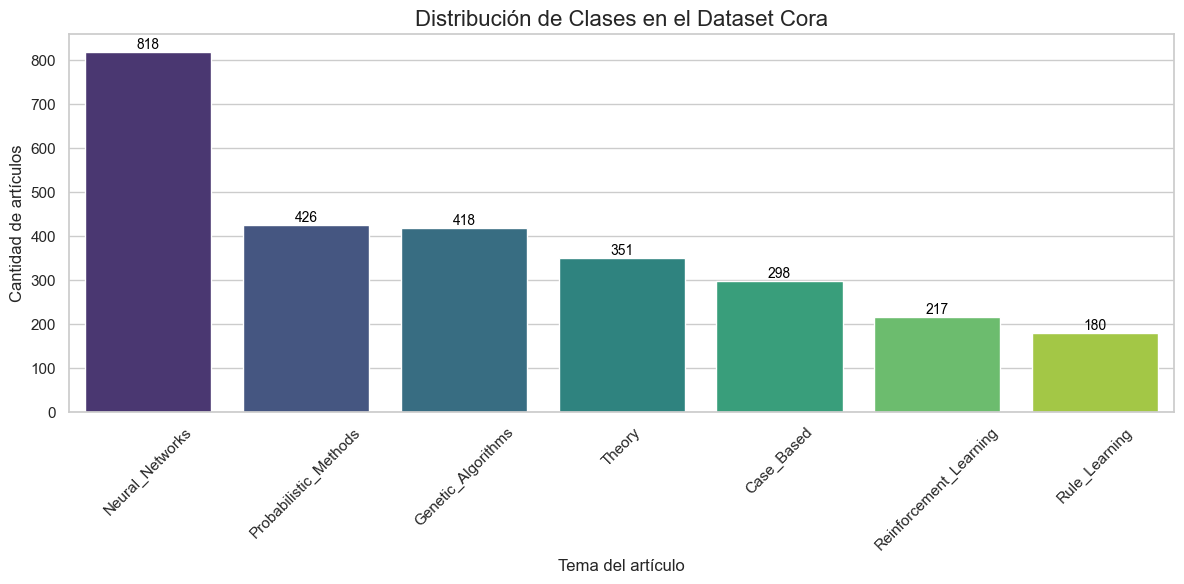

In [6]:
plt.figure(figsize=(12, 6))
order = df_nodes['label'].value_counts().index
ax = sns.countplot(data=df_nodes, x='label', hue='label', order=order, hue_order=order, palette='viridis', legend=False)
plt.title('Distribución de Clases en el Dataset Cora', fontsize=16)
plt.xlabel('Tema del artículo', fontsize=12)
plt.ylabel('Cantidad de artículos', fontsize=12)
plt.xticks(rotation=45)

# añade el conteo excato sabre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
# guardar figura
plt.savefig(figs_path / 'distribucion_clases_cora.png', dpi=300, bbox_inches='tight')
plt.show()



### 4.1 Interpretacion de la distribucion de clases

Como vemos en la representacion grafica, el dataset presenta un desequilibrio en la cantidad de artículos por tema.

La clase mayoritaria es "Neural Networks", mientras que temas como "Rule Learning" tienen menos representación en una proporción de 8:2. Los modelos de clasificación podrían tener dificultades para aprender patrones relevantes en las clases minoritarias, lo que podría resultar en un rendimiento deficiente para esas categorías. Este tipo de distribución puede requerir técnicas de balanceo de clases o enfoques específicos para manejar el desequilibrio durante el entrenamiento de modelos.

Las métricas de clasificación como la precisión, el recall y el F1-score podrían verse afectadas por este desequilibrio, un modelo mediocre podría obtener una alta precisión simplemente prediciendo la clase mayoritaria, pero tendría un recall muy bajo para las clases minoritarias. Por lo tanto, es importante considerar este desequilibrio al evaluar el rendimiento de los modelos y posiblemente utilizar métricas como el F1-score o la matriz de confusión para obtener una visión más completa del desempeño en todas las clases.

<a id="sec-5"></a>
## 5. Analisis de grados del grafo

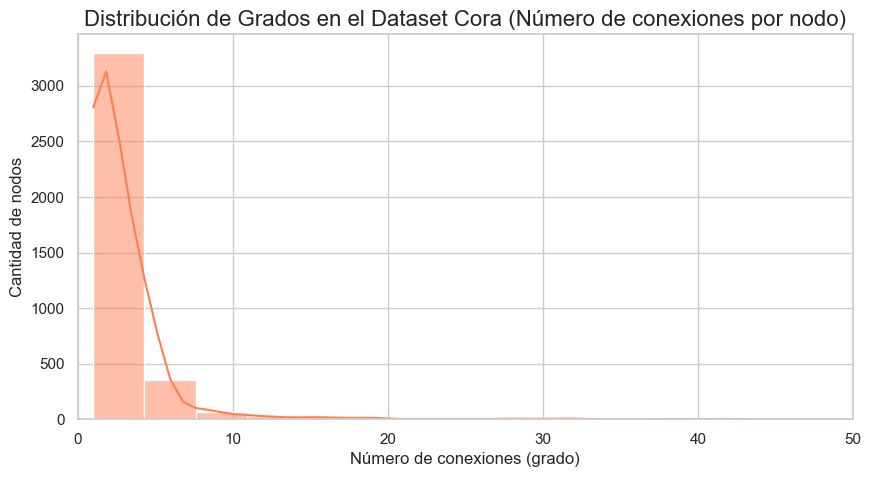

Grado máximo (nodo más conectado): 166
Grado promedio: 2.87


In [7]:
# Crear el grado con networkx
G = nx.from_pandas_edgelist(cora_cites, source='cited_paper_id', target='citing_paper_id')

# Calcular el grado de cada nodo (conexiones)
degrees = [G.degree(node) for node in G.nodes()]

plt.figure(figsize=(10, 5))
sns.histplot(degrees, bins=50, kde=True, color='coral')
plt.title('Distribución de Grados en el Dataset Cora (Número de conexiones por nodo)', fontsize=16)
plt.xlabel('Número de conexiones (grado)', fontsize=12)
plt.ylabel('Cantidad de nodos', fontsize=12)
plt.xlim(0, 50)  # Limitar el eje x para mejor visualización
# Guardar figura
plt.savefig(figs_path / 'distribucion_grados_cora.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Grado máximo (nodo más conectado): {max(degrees)}")
print(f"Grado promedio: {np.mean(degrees):.2f}")

### 5.1 Hallazgos sobre conectividad


#### 1. Es una red que sigue una "Ley de Potencias"

La conectividad no se distribuye de forma uniforme ni normal (no hay una "campana de Gauss" centrada en el promedio). En cambio, vemos una asimetría extrema hacia la derecha. Matemáticamente, este tipo de redes suele seguir una distribución de ley de potencias, expresada como $P(k) \sim k^{-\gamma}$.

* **En la práctica:** Nos dice que la inmensa mayoría de los artículos en la base de datos tienen muy pocas conexiones (la enorme barra inicial lo confirma). La mayoría de los *papers* solo citan o son citados por 1 a 3 trabajos, lo que explica por qué el grado promedio es tan bajo (2.87).

#### 2. La presencia de "Hubs" (Nodos súper-conectados)

La "cola larga" de la curva se extiende mucho más allá de donde se agrupa la masa de datos. Aunque tu gráfico corta el eje X visualmente alrededor de 50 para mantener la legibilidad, tu nota revela que hay al menos un nodo con **166 conexiones**.

* **En la práctica:** Estos son los "hubs" de la red. En el contexto de publicaciones científicas, representan artículos pioneros, metodologías estándar o *reviews* muy populares. Son las "superestrellas" que todo el mundo en esa subárea del Machine Learning cita para validar su propio trabajo.

#### 3. Consecuencias para el Machine Learning

Mirando esta distribución, sabemos inmediatamente a qué retos se enfrentará un modelo predictivo:

* **El sesgo de los Hubs:** Los algoritmos de grafos pueden sobreajustarse y darle demasiada importancia a los artículos súper-conectados, ya que su información "inunda" la red.
* **El problema de la escasez:** Como el ~80% de los nodos están en esa primera barra masiva, significa que la mayoría de los artículos tienen un "vecindario" muy pobre. El algoritmo tendrá muy pocas pistas externas (conexiones) para adivinar de qué trata ese artículo, dependiendo casi exclusivamente del propio texto del *paper*.

**En resumen:** La conectividad de Cora nos muestra un ecosistema muy desigual, dominado por unos pocos gigantes de la literatura científica, mientras que la inmensa mayoría de los artículos permanecen en la periferia con conexiones mínimas.


<a id="sec-6"></a>
## 6. Topologia local del grafo (subgrafo)

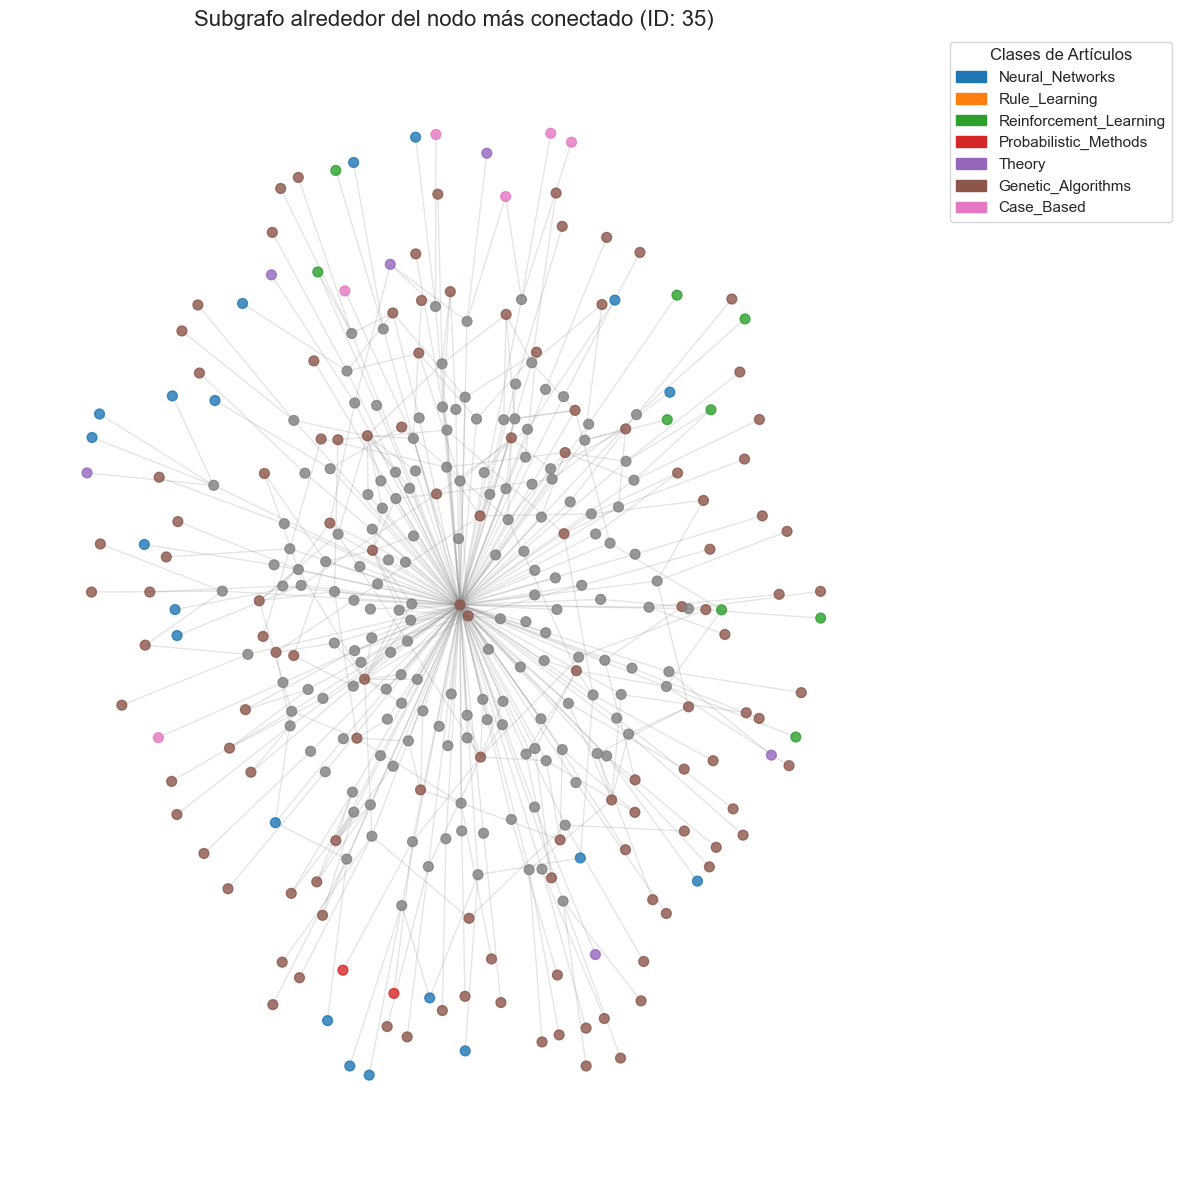

In [8]:
# Mapear colores a las clases para la visualización
unique_labels = df_nodes['label'].unique()
color_map_dict = {label: sns.color_palette("tab10")[i % 10] for i, label in enumerate(unique_labels)}
node_colors_dict = df_nodes.set_index('paper_id')['label'].map(color_map_dict).to_dict()

# Seleccionar el nodo con más conexiones para ver su vecindario
highest_degree_node = max(G.nodes, key=G.degree)
# Obtener los vecinos a distancia 1 y 2
ego_graph = nx.ego_graph(G, highest_degree_node, radius=2)

# Colores solo para los nodos en este subgrafo
colors = [node_colors_dict.get(node, (0.5, 0.5, 0.5)) for node in ego_graph.nodes()]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(ego_graph, seed=42, k=0.15) # k ajusta la distancia entre nodos
nx.draw_networkx_nodes(ego_graph, pos, node_size=50, node_color=colors, alpha=0.8)
nx.draw_networkx_edges(ego_graph, pos, alpha=0.2, edge_color='gray')

# Crear leyenda
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=color_map_dict[label], label=label) for label in unique_labels]
plt.legend(handles=legend_handles, title="Clases de Artículos", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title(f'Subgrafo alrededor del nodo más conectado (ID: {highest_degree_node})', fontsize=16)
plt.axis('off')
plt.tight_layout()
# guardar figura
plt.savefig(figs_path / 'subgrafo_nodo_mas_conectado_cora.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.1 Análisis de subgrafo


#### 1. El fenómeno de la "Homofilia" (Lo similar atrae a lo similar)

Esta es la conclusión más importante a simple vista. El nodo central (ID 35) pertenece a la clase **Genetic_Algorithms** (color marrón). Si nos fijamos en la nube de nodos que lo rodean y lo citan (o son citados por él), **la inmensa mayoría también son marrones**.

* **En la vida real:** Esto significa que los investigadores de algoritmos genéticos tienden a citar abrumadoramente otros *papers* de algoritmos genéticos. En el análisis de redes, esta tendencia de los nodos a conectarse con otros nodos de su misma clase se llama **homofilia**.

#### 2. El rol de un "Paper Seminal"

Al ser el nodo más conectado (como vimos en el histograma anterior, con 166 conexiones), y estar rodeado de su propia disciplina, podemos deducir que el artículo 35 no es un *paper* cualquiera. Es probablemente un **artículo fundacional o una revisión exhaustiva (*survey*)** sobre algoritmos genéticos que todo el mundo en ese nicho se siente obligado a citar.

#### 3. Conexiones Interdisciplinares (Fronteras porosas)

Aunque el marrón domina, el grafo no es puro. Vemos salpicaduras de otros colores interactuando con el hub central:

* Nodos azules (**Neural_Networks**)
* Nodos morados (**Theory**)
* Nodos verdes (**Reinforcement_Learning**)
* **Conclusión:** Aunque la ciencia está muy parcelada (homofilia), este artículo es lo suficientemente importante como para que otras disciplinas del *Machine Learning* crucen la frontera para citarlo (por ejemplo, alguien usando algoritmos genéticos para optimizar una red neuronal).

#### 4. La ventaja táctica para las Redes Neuronales de Grafos (GNNs)

Esta imagen es la prueba visual de por qué usamos GNNs. Si ocultamos el color del nodo central y le pedimos a una IA que lo adivine mirando solo su texto (sus palabras clave), podría equivocarse.
Pero si el algoritmo usa **agregación de vecindarios** (mirar quiénes son sus amigos), verá que está rodeado de decenas de nodos marrones. Matemáticamente, la red deducirá: *"Si camina como un algoritmo genético y se junta con algoritmos genéticos, debe ser un algoritmo genético"*.

<a id="sec-7"></a>
## 7. Analisis de propiedades nativas

--- Análisis de Propiedades Nativas ---
Dimensiones de la matriz de características: (2708, 1433)
Porcentaje de dispersión (Sparsity): 98.73%
Promedio de palabras clave (atributos) presentes por artículo: 18.17


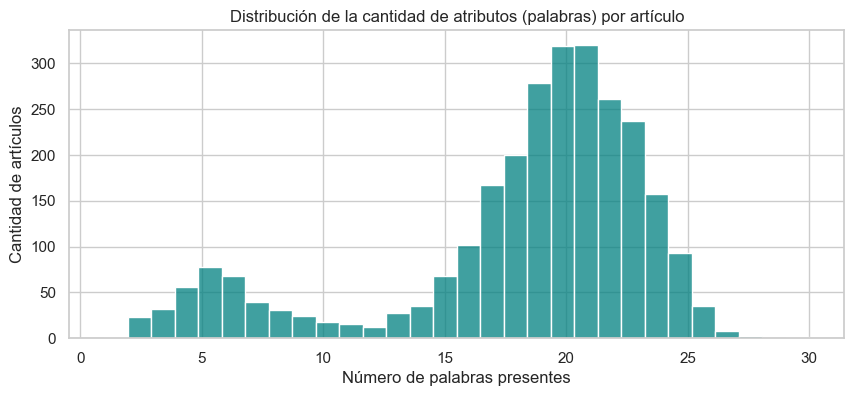

In [9]:

# features es el dataframe que contiene las 1433 columnas de palabras
print("--- Análisis de Propiedades Nativas ---")
total_elementos = features.size
valores_activos = features.sum().sum() # Suma de todos los 1s
sparsity = 100 - ((valores_activos / total_elementos) * 100)

print(f"Dimensiones de la matriz de características: {features.shape}")
print(f"Porcentaje de dispersión (Sparsity): {sparsity:.2f}%")
print(f"Promedio de palabras clave (atributos) presentes por artículo: {valores_activos / len(features):.2f}")

# Visualizar cuántos atributos tiene cada artículo
plt.figure(figsize=(10, 4))
sns.histplot(features.sum(axis=1), bins=30, color='teal')
plt.title('Distribución de la cantidad de atributos (palabras) por artículo')
plt.xlabel('Número de palabras presentes')
plt.ylabel('Cantidad de artículos')

# guardar figura
plt.savefig(figs_path / 'distribucion_palabras_por_articulo_cora.png', dpi=300, bbox_inches='tight')    
plt.show()



### 7.1 Análisis de palabras clave

#### 1. Extrema Dispersión (Sparsity del 98.73%)

El dato más impactante del texto superior es la dispersión. Tenemos un diccionario posible de 1.433 palabras clave, pero en promedio, un artículo solo contiene unas 18 palabras (`18.17`).

* **Qué significa técnicamente:** La matriz de características está llena de ceros. El 98.73% de los datos son literalmente la ausencia de una palabra.
* **Implicación en hardware:** Si intentas cargar esto en la memoria RAM como una tabla de Excel normal (matriz densa), el ordenador desperdiciará muchísima memoria almacenando ceros. Es obligatorio usar estructuras de datos especiales llamadas **matrices dispersas** (*sparse matrices*).

#### 2. Una intrigante Distribución Bimodal

Si miramos la forma del histograma, vemos que no es una sola montaña, sino que tiene **dos picos (es bimodal)**:

* Hay un grupo pequeño de artículos a la izquierda que apenas tienen entre **3 y 7 palabras clave**.
* Hay un grupo masivo a la derecha que se concentra alrededor de las **20-22 palabras clave**.
* **Hipótesis:** Esto nos dice que los artículos no son homogéneos. Ese grupo pequeño a la izquierda podrían ser *abstracts* muy cortos, reseñas, o documentos que el sistema original no pudo leer bien al extraer el texto. Esos nodos con casi nula información textual serán los más difíciles de clasificar.

#### 3. La justificación definitiva para usar Grafos

Si ignoramos las conexiones de citación que vimos en el gráfico anterior e intentamos predecir de qué trata un artículo usando **solo** estas características nativas (usando un Random Forest o una Red Neuronal clásica).

Al modelo le costaría muchísimo. Tratar de adivinar si un *paper* es sobre "Redes Neuronales" o "Algoritmos Genéticos" leyendo únicamente 18 palabras sueltas sin orden (y a veces solo 5), es una tarea casi imposible por la falta de contexto.

Por eso el dataset Cora es tan famoso para probar algoritmos de grafos: **te obliga a usar las conexiones para compensar la pobreza del texto**. Si un nodo solo tiene 4 palabras clave (poca información nativa), el algoritmo mirará a quién cita (su vecindario) para poder clasificarlo correctamente.

<a id="sec-8"></a>
## 8. Conclusiones y siguientes pasos

- El EDA confirma la estructura multiclase del problema y permite anticipar posibles efectos de desbalance.
- La topologia del grafo aporta contexto relacional util para extraer caracteristicas en la Tarea 1.4.
- Este analisis deja lista la base para construir variables relacionales y luego evaluar su impacto en modelado.